In [1]:
import spcm
from spcm import units
import numpy as np
import matplotlib.pyplot as plt
# import packages
from Equipments import BNC575, Weeder, SR400, MCBOX, Andor, Agilent, ThorlabsPM, LeCroyScope
from Equipments.MCBOX import generate_test_voltages
from DataProcessing.Plot import PlotSaver

import pyvisa
import time

from scipy.signal import find_peaks
from scipy.optimize import curve_fit

In [2]:
rm = pyvisa.ResourceManager()
print(rm.list_resources())

('ASRL1::INSTR', 'ASRL2::INSTR', 'ASRL3::INSTR', 'ASRL4::INSTR', 'ASRL5::INSTR', 'ASRL6::INSTR', 'ASRL7::INSTR', 'GPIB0::9::INSTR', 'TCPIP0::169.254.110.10::inst0::INSTR', 'USB0::0x1313::0x807B::241023118::0::INSTR')


In [19]:
lecroyscope = LeCroyScope.LeCroyScope('GPIB0::3::INSTR')

*IDN -> LECROY,9354AM,935403739,08.2.1



In [21]:
t,v,info = lecroyscope.read_waveform("C1")

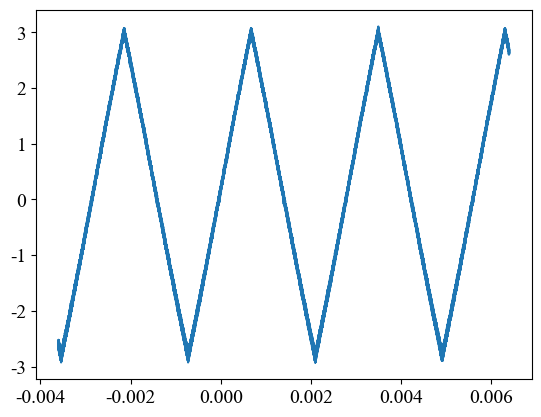

In [22]:
plt.plot(t,v)

In [2]:
card = None

In [3]:

if not card:
    card = spcm.Card('/dev/spcm0', verbose=True).open()

Python version: 3.12.7 on Windows
Driver version: 7.7.23371
Kernel version: 6.3.22848
Found '/dev/spcm0': M4i.6622-x8 sn 23161


In [4]:
card.card_mode(spcm.SPC_REP_STD_CONTINUOUS)
card.timeout(50 * units.s) # 10 s; 0 = disable timeout functionality
card.loops(0); # 0 = loop endless; >0 = n times

In [5]:
channels = spcm.Channels(card, card_enable=spcm.CHANNEL0)
channels.enable(True);
# channels.output_load(units.highZ)
channels.output_load(50*units.ohm);
channels.amp(2 * units.V);

In [6]:
clock = spcm.Clock(card)
clock.mode(spcm.SPC_CM_INTPLL)
clock.sample_rate(100*units.percent);
clock.clock_output(False);

In [7]:
trigger = spcm.Trigger(card)
trigger.or_mask(spcm.SPC_TMASK_SOFTWARE);

In [8]:
num_samples = 1 * units.MiS

data_transfer = spcm.DataTransfer(card)
if data_transfer.bytes_per_sample != 2: raise spcm.SpcmException(text="Non 16-bit DA not supported")
data_transfer.memory_size(num_samples) # size of memory on the card
data_transfer.allocate_buffer(num_samples) # size of buffer in pc RAM

# generate output data (or alternatively load data from file)
num_samples_magnitude = num_samples.to_base_units().magnitude
# simple ramp for analog output cards
data_transfer.buffer[:] = np.arange(-num_samples_magnitude//2, num_samples_magnitude//2).astype(np.int16) # saw-tooth signal

data_transfer.start_buffer_transfer(spcm.M2CMD_DATA_STARTDMA, spcm.M2CMD_DATA_WAITDMA) # Wait until the writing to buffer has been done

Starting the DMA transfer and waiting until data is in board memory
... data transfer started


In [ ]:
num_samples = 1 * units.MiS

data_transfer = spcm.DataTransfer(card)
if data_transfer.bytes_per_sample != 2: raise spcm.SpcmException(text="Non 16-bit DA not supported")
data_transfer.memory_size(num_samples) # size of memory on the card
data_transfer.allocate_buffer(num_samples) # size of buffer in pc RAM

# generate output data (or alternatively load data from file)
num_samples_magnitude = num_samples.to_base_units().magnitude
# simple ramp for analog output cards
data_transfer.buffer[:] = np.arange(-num_samples_magnitude//2, num_samples_magnitude//2).astype(np.int16) # saw-tooth signal

data_transfer.start_buffer_transfer(spcm.M2CMD_DATA_STARTDMA, spcm.M2CMD_DATA_WAITDMA) # Wait until the writing to buffer has been done

In [ ]:
print("Starting the card and waiting for ready interrupt")
try:
    card.start(spcm.M2CMD_CARD_ENABLETRIGGER, spcm.M2CMD_CARD_WAITREADY)
except spcm.SpcmTimeout as timeout:
    print("-> The 10 seconds timeout have passed and the card is stopped")

# Without the above "spcm.M2CMD_CARD_WAITREADY" flag you can do things here in parallel
# and later stop the replaying with "card.stop()"

print("Finished replaying...")
card.stop()

In [10]:
print("Starting the card and waiting for ready interrupt")
try:
    card.start(spcm.M2CMD_CARD_ENABLETRIGGER, spcm.M2CMD_CARD_WAITREADY)
except spcm.SpcmTimeout as timeout:
    print("-> The 10 seconds timeout have passed and the card is stopped")

# Without the above "spcm.M2CMD_CARD_WAITREADY" flag you can do things here in parallel
# and later stop the replaying with "card.stop()"

print("Finished replaying...")
card.stop()

Starting the card and waiting for ready interrupt
-> The 10 seconds timeout have passed and the card is stopped
Finished replaying...


In [23]:
card.close()
lecroyscope.close()

In [ ]:
sample_rate = 625 #MS/s

